# 05 — Explainability: Grad-CAM & Attention Rollout

**Student:** Shree Ramji | ec25075@qmul.ac.uk  
**Institution:** Queen Mary University of London  
**Programme:** MSc Machine Learning for Visual Data Analytics  

---

## Objective

Apply explainability techniques to the three trained classification models to understand which image regions influence their predictions.

- **ResNet50** → Grad-CAM on `layer4[-1]` (last residual block)
- **DenseNet121** → Grad-CAM on `features.denseblock4.denselayer16.conv2`
- **ViT-B/16** → GradCAM with `reshape_transform` on last attention block + Attention Rollout

## Why Explainability Matters

- Validates model learns clinically relevant features — not spurious correlations
- Identifies failure modes — what does the model attend to on wrong predictions?
- Required for trustworthy AI in medical imaging
- Addresses the "black box" criticism of deep learning in healthcare
- Regulatory requirement for clinical AI deployment (EU AI Act, FDA guidance)

## Sections

1. Install & Imports
2. Load All Three Models
3. Load and Preprocess Test Images
4. Verify Model Predictions
5. Grad-CAM — ResNet50
6. Grad-CAM — DenseNet121
7. GradCAM — ViT-B/16 (with reshape_transform)
8. Attention Rollout — ViT-B/16
9. Side-by-Side Comparison Grid
10. Per-Class Analysis
11. Wrong Prediction Analysis
12. Clinical Alignment Table
13. Summary

In [1]:
!pip install grad-cam timm --quiet
print("✓ grad-cam and timm installed")

✓ grad-cam and timm installed


In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import timm
import warnings
warnings.filterwarnings('ignore')

# Grad-CAM imports
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"GPU    : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Paths
MODEL_DIR  = Path('models')
CNN_TEST   = Path('data/processed/cnn/test')
OUTPUT_DIR = Path('outputs/gradcam')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Class names — alphabetical order (matches ImageFolder training)
CLASS_NAMES = ['Caries', 'Deep_Caries', 'Impacted', 'Periapical_Lesion']
NUM_CLASSES = 4

print(f"\nClass mapping:")
for i, cls in enumerate(CLASS_NAMES):
    print(f"  {i}: {cls}")

[HAMI-core Msg(547:140030575222080:libvgpu.c:839)]: Initializing.....
/opt/conda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : cuda
GPU    : NVIDIA A100 80GB PCIe

Class mapping:
  0: Caries
  1: Deep_Caries
  2: Impacted
  3: Periapical_Lesion


[HAMI-core Msg(547:140030575222080:libvgpu.c:855)]: Initialized


## 1. Load All Three Models

Rebuilding each architecture exactly as during Phase 3 training, then loading saved weights.
Architecture must match exactly — PyTorch `load_state_dict` requires identical layer names and shapes.

In [3]:
# ── ResNet50 ──────────────────────────────────────────────────────────────
resnet50 = models.resnet50(weights=None)
resnet50.fc = nn.Linear(resnet50.fc.in_features, NUM_CLASSES)
resnet50.load_state_dict(torch.load(MODEL_DIR / 'resnet50_best.pt', map_location=device))
resnet50 = resnet50.to(device).eval()
print("✓ ResNet50 loaded")

# ── DenseNet121 ───────────────────────────────────────────────────────────
densenet121 = models.densenet121(weights=None)
densenet121.classifier = nn.Linear(densenet121.classifier.in_features, NUM_CLASSES)
densenet121.load_state_dict(torch.load(MODEL_DIR / 'densenet121_best.pt', map_location=device))
densenet121 = densenet121.to(device).eval()
print("✓ DenseNet121 loaded")

# ── ViT-B/16 ──────────────────────────────────────────────────────────────
vit = timm.create_model('vit_base_patch16_224', pretrained=False, num_classes=NUM_CLASSES)
vit.load_state_dict(torch.load(MODEL_DIR / 'vit_best.pt', map_location=device))
vit = vit.to(device).eval()
print("✓ ViT-B/16 loaded")

# Verify parameter counts match Phase 3
print("\nParameter counts:")
for name, mdl in [('ResNet50', resnet50), ('DenseNet121', densenet121), ('ViT-B/16', vit)]:
    total = sum(p.numel() for p in mdl.parameters())
    print(f"  {name:<15} {total:>12,}")

✓ ResNet50 loaded
✓ DenseNet121 loaded
✓ ViT-B/16 loaded

Parameter counts:
  ResNet50          23,516,228
  DenseNet121        6,957,956
  ViT-B/16          85,801,732


## 2. Load and Preprocess Test Images

Using the three confident correct predictions found during pre-check:
- `Caries` → test_119.png (ResNet50 conf=0.761)
- `Impacted` → test_105.png (ResNet50 conf=0.975)
- `Periapical_Lesion` → test_192.png (ResNet50 conf=0.726)

`Deep_Caries` excluded — zero test annotations in DENTEX, no test images available.

Each image loaded in two formats:
1. **Tensor** — normalised, for model inference and Grad-CAM gradients
2. **RGB numpy float32 [0,1]** — un-normalised, for `show_cam_on_image` overlay

In [4]:
# Must match Phase 3 training preprocessing exactly
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Good samples — found during pre-check (ResNet50 correct predictions)
GOOD_SAMPLES = {
    'Caries'           : CNN_TEST / 'Caries'            / 'test_119.png',
    'Impacted'         : CNN_TEST / 'Impacted'           / 'test_105.png',
    'Periapical_Lesion': CNN_TEST / 'Periapical_Lesion'  / 'test_192.png',
}

images_tensor = {}   # class_name -> tensor (1, 3, 224, 224) on device
images_rgb    = {}   # class_name -> numpy (224, 224, 3) float32 0-1 for overlay

for cls_name, img_path in GOOD_SAMPLES.items():
    img_pil         = Image.open(img_path).convert('RGB')
    img_pil_resized = img_pil.resize((224, 224))

    # Tensor for model inference + Grad-CAM
    tensor = transform(img_pil).unsqueeze(0).to(device)
    images_tensor[cls_name] = tensor

    # RGB numpy float32 0-1 for show_cam_on_image
    img_np = np.array(img_pil_resized).astype(np.float32) / 255.0
    images_rgb[cls_name] = img_np

    print(f"✓ {cls_name:<25} {img_path.name}  shape={tensor.shape}")

✓ Caries                    test_119.png  shape=torch.Size([1, 3, 224, 224])
✓ Impacted                  test_105.png  shape=torch.Size([1, 3, 224, 224])
✓ Periapical_Lesion         test_192.png  shape=torch.Size([1, 3, 224, 224])


## 3. Verify Model Predictions

Confirm all three models predict correctly on the selected test images before running Grad-CAM.
Grad-CAM on wrong predictions is meaningful only when intentional (Section 11).

In [5]:
print("Prediction verification — all models on all test images")
print("=" * 80)
print(f"{'True Class':<22} {'ResNet50':<25} {'DenseNet121':<25} {'ViT-B/16':<25}")
print("-" * 80)

for cls_name, tensor in images_tensor.items():
    preds = []
    for mdl in [resnet50, densenet121, vit]:
        with torch.no_grad():
            out  = mdl(tensor)
            prob = torch.softmax(out, dim=1)
            pred = prob.argmax(1).item()
            conf = prob.max().item()
            correct = "✓" if CLASS_NAMES[pred] == cls_name else "✗"
            preds.append(f"{correct} {CLASS_NAMES[pred][:12]}({conf:.2f})")
    print(f"  {cls_name:<20} {preds[0]:<25} {preds[1]:<25} {preds[2]:<25}")

Prediction verification — all models on all test images
True Class             ResNet50                  DenseNet121               ViT-B/16                 
--------------------------------------------------------------------------------
  Caries               ✓ Caries(0.76)            ✓ Caries(0.68)            ✓ Caries(0.89)           
  Impacted             ✓ Impacted(0.98)          ✓ Impacted(0.90)          ✓ Impacted(0.89)         
  Periapical_Lesion    ✓ Periapical_L(0.72)      ✓ Periapical_L(0.36)      ✓ Periapical_L(0.70)     


## 4. Grad-CAM — ResNet50

**Target layer:** `model.layer4[-1]` — last residual block before global average pooling.
This is the standard Grad-CAM target for ResNet — produces 7×7 feature maps upsampled to 224×224.

Grad-CAM works by:
1. Forward pass → get class score
2. Backpropagate class score to target layer
3. Global average pool the gradients → importance weights per channel
4. Weighted sum of feature maps → heatmap
5. ReLU + normalise + upsample to input size

✓ Grad-CAM complete — ResNet50


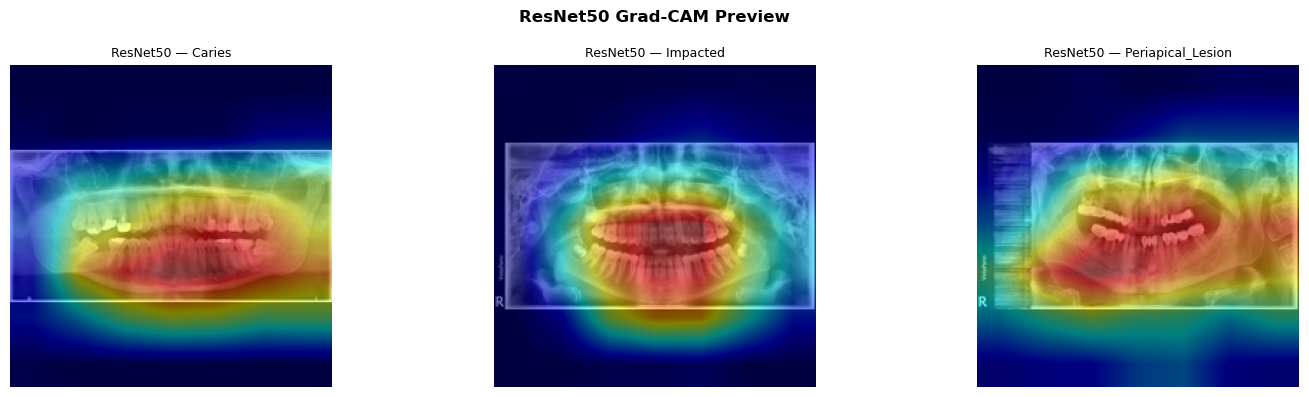

Saved: outputs/gradcam/resnet50_gradcam_preview.png


In [6]:
def run_gradcam(model, target_layers, images_tensor, images_rgb,
                class_names, model_name, reshape_transform=None):
    """
    Run Grad-CAM on all good sample images.
    Returns dict: class_name -> {original, heatmap, overlay}
    """
    cam = GradCAM(model=model, target_layers=target_layers,
                  reshape_transform=reshape_transform)
    results = {}

    for cls_name, tensor in images_tensor.items():
        cls_idx = class_names.index(cls_name)
        targets = [ClassifierOutputTarget(cls_idx)]

        grayscale_cam = cam(input_tensor=tensor, targets=targets)
        grayscale_cam = grayscale_cam[0]  # (224, 224)

        rgb_img = images_rgb[cls_name]
        overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        results[cls_name] = {
            'original': (rgb_img * 255).astype(np.uint8),
            'heatmap' : grayscale_cam,
            'overlay' : overlay
        }

    print(f"✓ Grad-CAM complete — {model_name}")
    return results


# ResNet50 — last residual block
resnet_target   = [resnet50.layer4[-1]]
resnet_results  = run_gradcam(
    resnet50, resnet_target, images_tensor, images_rgb, CLASS_NAMES, 'ResNet50'
)

# Quick preview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cls_name in zip(axes, GOOD_SAMPLES.keys()):
    ax.imshow(resnet_results[cls_name]['overlay'])
    ax.set_title(f'ResNet50 — {cls_name}', fontsize=9)
    ax.axis('off')
plt.suptitle('ResNet50 Grad-CAM Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'resnet50_gradcam_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/gradcam/resnet50_gradcam_preview.png")

## 5. Grad-CAM — DenseNet121

**Target layer:** `model.features.denseblock4.denselayer16.conv2` — last conv in the final dense block.

DenseNet architecture note: each denselayer has two convolutions (conv1=1×1 bottleneck, conv2=3×3 output).
`denselayer16.conv2` is the last 3×3 conv before the transition/final BatchNorm — produces spatial feature maps suitable for Grad-CAM.

✓ Grad-CAM complete — DenseNet121


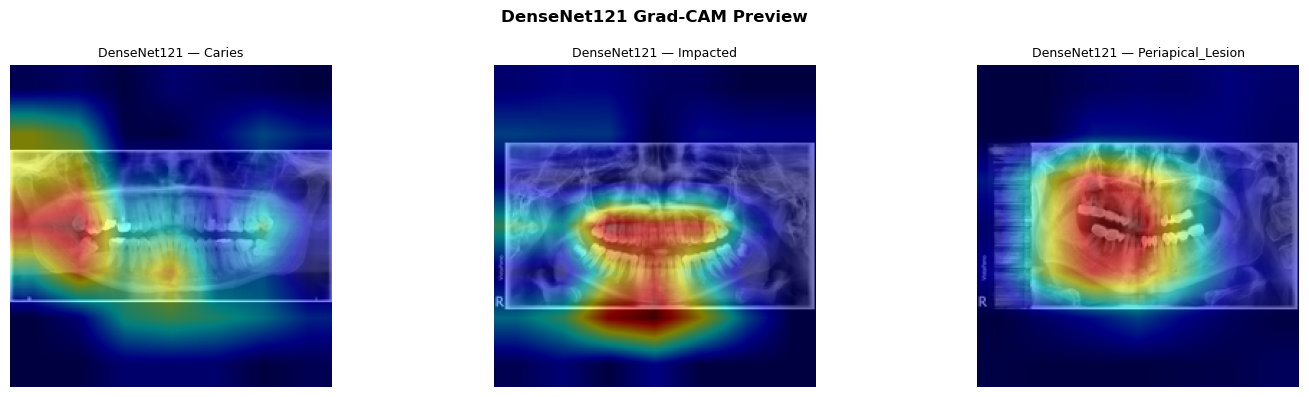

Saved: outputs/gradcam/densenet121_gradcam_preview.png


In [7]:
# DenseNet121 — last conv in final dense block
densenet_target  = [densenet121.features.denseblock4.denselayer16.conv2]
densenet_results = run_gradcam(
    densenet121, densenet_target, images_tensor, images_rgb, CLASS_NAMES, 'DenseNet121'
)

# Quick preview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cls_name in zip(axes, GOOD_SAMPLES.keys()):
    ax.imshow(densenet_results[cls_name]['overlay'])
    ax.set_title(f'DenseNet121 — {cls_name}', fontsize=9)
    ax.axis('off')
plt.suptitle('DenseNet121 Grad-CAM Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'densenet121_gradcam_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/gradcam/densenet121_gradcam_preview.png")

In [8]:
# Save individual model Grad-CAM outputs for dissertation use
for model_name, results in [('resnet50', resnet_results), ('densenet121', densenet_results)]:
    for cls_name, data in results.items():
        fig, ax = plt.subplots(1, 1, figsize=(6, 4))
        ax.imshow(data['overlay'])
        ax.set_title(f'{model_name.upper()} Grad-CAM — {cls_name}', fontweight='bold')
        ax.axis('off')
        save_path = OUTPUT_DIR / f'{model_name}_{cls_name.lower()}.png'
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()
print("✓ Individual CNN Grad-CAM images saved to outputs/gradcam/")

✓ Individual CNN Grad-CAM images saved to outputs/gradcam/


## 6. GradCAM — ViT-B/16 (with reshape_transform)

ViT has no convolutional feature maps — it outputs token sequences.
To apply Grad-CAM we must reshape the token output back into a spatial grid.

**reshape_transform:** removes CLS token, reshapes remaining 196 tokens (14×14 patches) into a (B, C, 14, 14) feature map that Grad-CAM can process.

**Target layer:** `vit.blocks[-1].norm1` — last transformer block's layer norm before attention. Gradients here reflect the final spatial attention pattern before classification.

✓ Grad-CAM complete — ViT-B/16


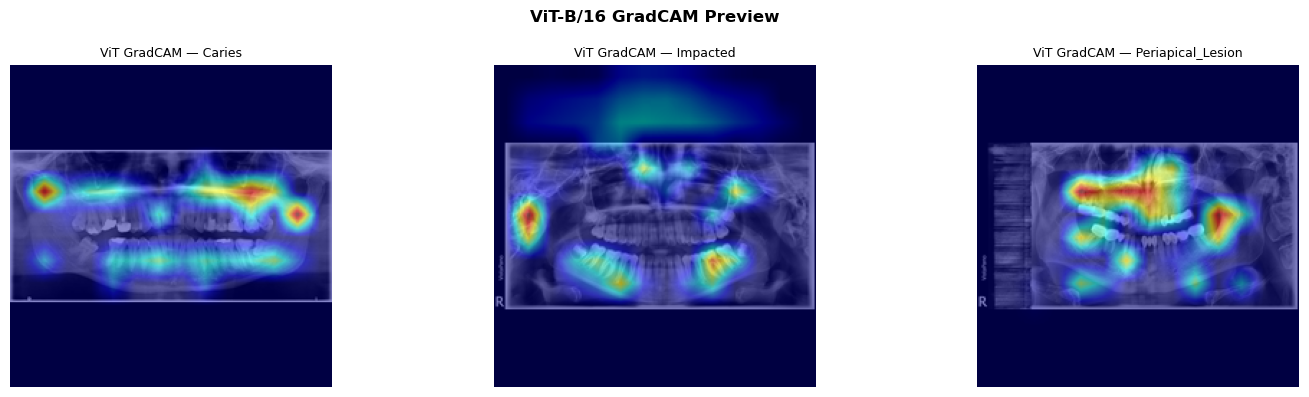

Saved: outputs/gradcam/vit_gradcam_preview.png


In [9]:
def reshape_transform_vit(tensor, height=14, width=14):
    """
    ViT outputs (B, num_tokens, embed_dim) — not spatial.
    Remove CLS token (index 0), reshape patch tokens to spatial grid.
    14x14 = 196 patches because 224/16 = 14 patches per side.
    Output: (B, embed_dim, 14, 14) — compatible with Grad-CAM.
    """
    result = tensor[:, 1:, :]   # remove CLS token → (B, 196, 768)
    result = result.reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)   # → (B, 768, 14, 14)
    return result


# ViT GradCAM — last transformer block norm
vit_target = [vit.blocks[-1].norm1]
vit_gradcam_results = run_gradcam(
    vit, vit_target, images_tensor, images_rgb, CLASS_NAMES, 'ViT-B/16',
    reshape_transform=reshape_transform_vit
)

# Quick preview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cls_name in zip(axes, GOOD_SAMPLES.keys()):
    ax.imshow(vit_gradcam_results[cls_name]['overlay'])
    ax.set_title(f'ViT GradCAM — {cls_name}', fontsize=9)
    ax.axis('off')
plt.suptitle('ViT-B/16 GradCAM Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vit_gradcam_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/gradcam/vit_gradcam_preview.png")

## 7. Attention Rollout — ViT-B/16

Attention Rollout (Abnar & Zuidema, 2020) propagates attention maps across all transformer layers to produce a global attention map from input to output.

**Algorithm:**
1. Hook all attention blocks — capture attention weights during forward pass
2. Average over attention heads per layer
3. Add residual connections (identity matrix)
4. Matrix-multiply attention maps across all layers (rollout)
5. Extract CLS token row — shows which patches the model attends to globally

**Difference from Grad-CAM:** Attention Rollout is gradient-free — it shows attention directly, not gradient-weighted activation.

fused_attn disabled: False
  Captures: 12, shape: torch.Size([1, 12, 197, 197])
✓ Attention Rollout — Caries
  Captures: 12, shape: torch.Size([1, 12, 197, 197])
✓ Attention Rollout — Impacted
  Captures: 12, shape: torch.Size([1, 12, 197, 197])
✓ Attention Rollout — Periapical_Lesion


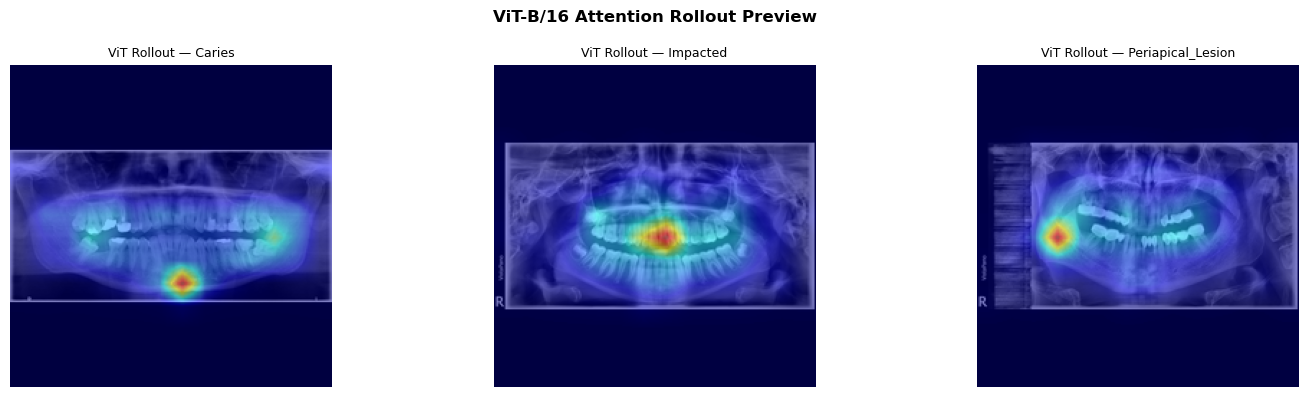

Saved: outputs/gradcam/vit_rollout_preview.png


In [10]:
# Disable fused attention on every block — required for attn_drop hook to fire
# timm ViT uses fused_attn=True by default (F.scaled_dot_product_attention)
# which bypasses attn_drop entirely, making hook capture return empty
for block in vit.blocks:
    block.attn.fused_attn = False
print(f"fused_attn disabled: {vit.blocks[0].attn.fused_attn}")


def attention_rollout(model, tensor, discard_ratio=0.9):
    """
    Attention Rollout (Abnar & Zuidema, 2020).
    Requires fused_attn=False (set above) to capture attention weights via attn_drop hook.
    Returns: (224, 224) numpy array, normalised 0-1.
    """
    attentions = []
    hooks      = []

    def hook_fn(module, input, output):
        attentions.append(output.detach().cpu())

    for block in model.blocks:
        hooks.append(block.attn.attn_drop.register_forward_hook(hook_fn))

    with torch.no_grad():
        _ = model(tensor)

    for hook in hooks:
        hook.remove()

    print(f"  Captures: {len(attentions)}, shape: {attentions[0].shape if attentions else 'EMPTY'}")

    if not attentions or attentions[0].ndim < 4:
        print("  Warning: not captured — uniform fallback")
        return np.ones((224, 224), dtype=np.float32)

    n_tokens = attentions[0].shape[-1]
    result   = torch.eye(n_tokens)

    for attn in attentions:
        attn_avg = attn.mean(dim=1)[0]
        attn_res = attn_avg + torch.eye(n_tokens)
        attn_res = attn_res / attn_res.sum(dim=-1, keepdim=True)
        flat      = attn_res.flatten()
        threshold = flat.quantile(discard_ratio)
        attn_res[attn_res < threshold] = 0
        result = torch.matmul(attn_res, result)

    mask  = result[0, 1:].numpy()
    width = int(mask.shape[0] ** 0.5)
    mask  = mask.reshape(width, width)
    mask  = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)
    return cv2.resize(mask, (224, 224))


# Run attention rollout on all good samples
vit_rollout_results = {}
for cls_name, tensor in images_tensor.items():
    rgb_img = images_rgb[cls_name]
    rollout = attention_rollout(vit, tensor)
    overlay = show_cam_on_image(rgb_img, rollout, use_rgb=True)
    vit_rollout_results[cls_name] = {
        'original': (rgb_img * 255).astype(np.uint8),
        'heatmap' : rollout,
        'overlay' : overlay
    }
    print(f"✓ Attention Rollout — {cls_name}")

# Quick preview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, cls_name in zip(axes, GOOD_SAMPLES.keys()):
    ax.imshow(vit_rollout_results[cls_name]['overlay'])
    ax.set_title(f'ViT Rollout — {cls_name}', fontsize=9)
    ax.axis('off')
plt.suptitle('ViT-B/16 Attention Rollout Preview', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'vit_rollout_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/gradcam/vit_rollout_preview.png")

## 8. Side-by-Side Comparison Grid

Rows = disease classes. Columns = Original | ResNet50 | DenseNet121 | ViT GradCAM | ViT Rollout.

This is the primary visualisation for the dissertation — shows all four explainability outputs side by side for direct comparison.

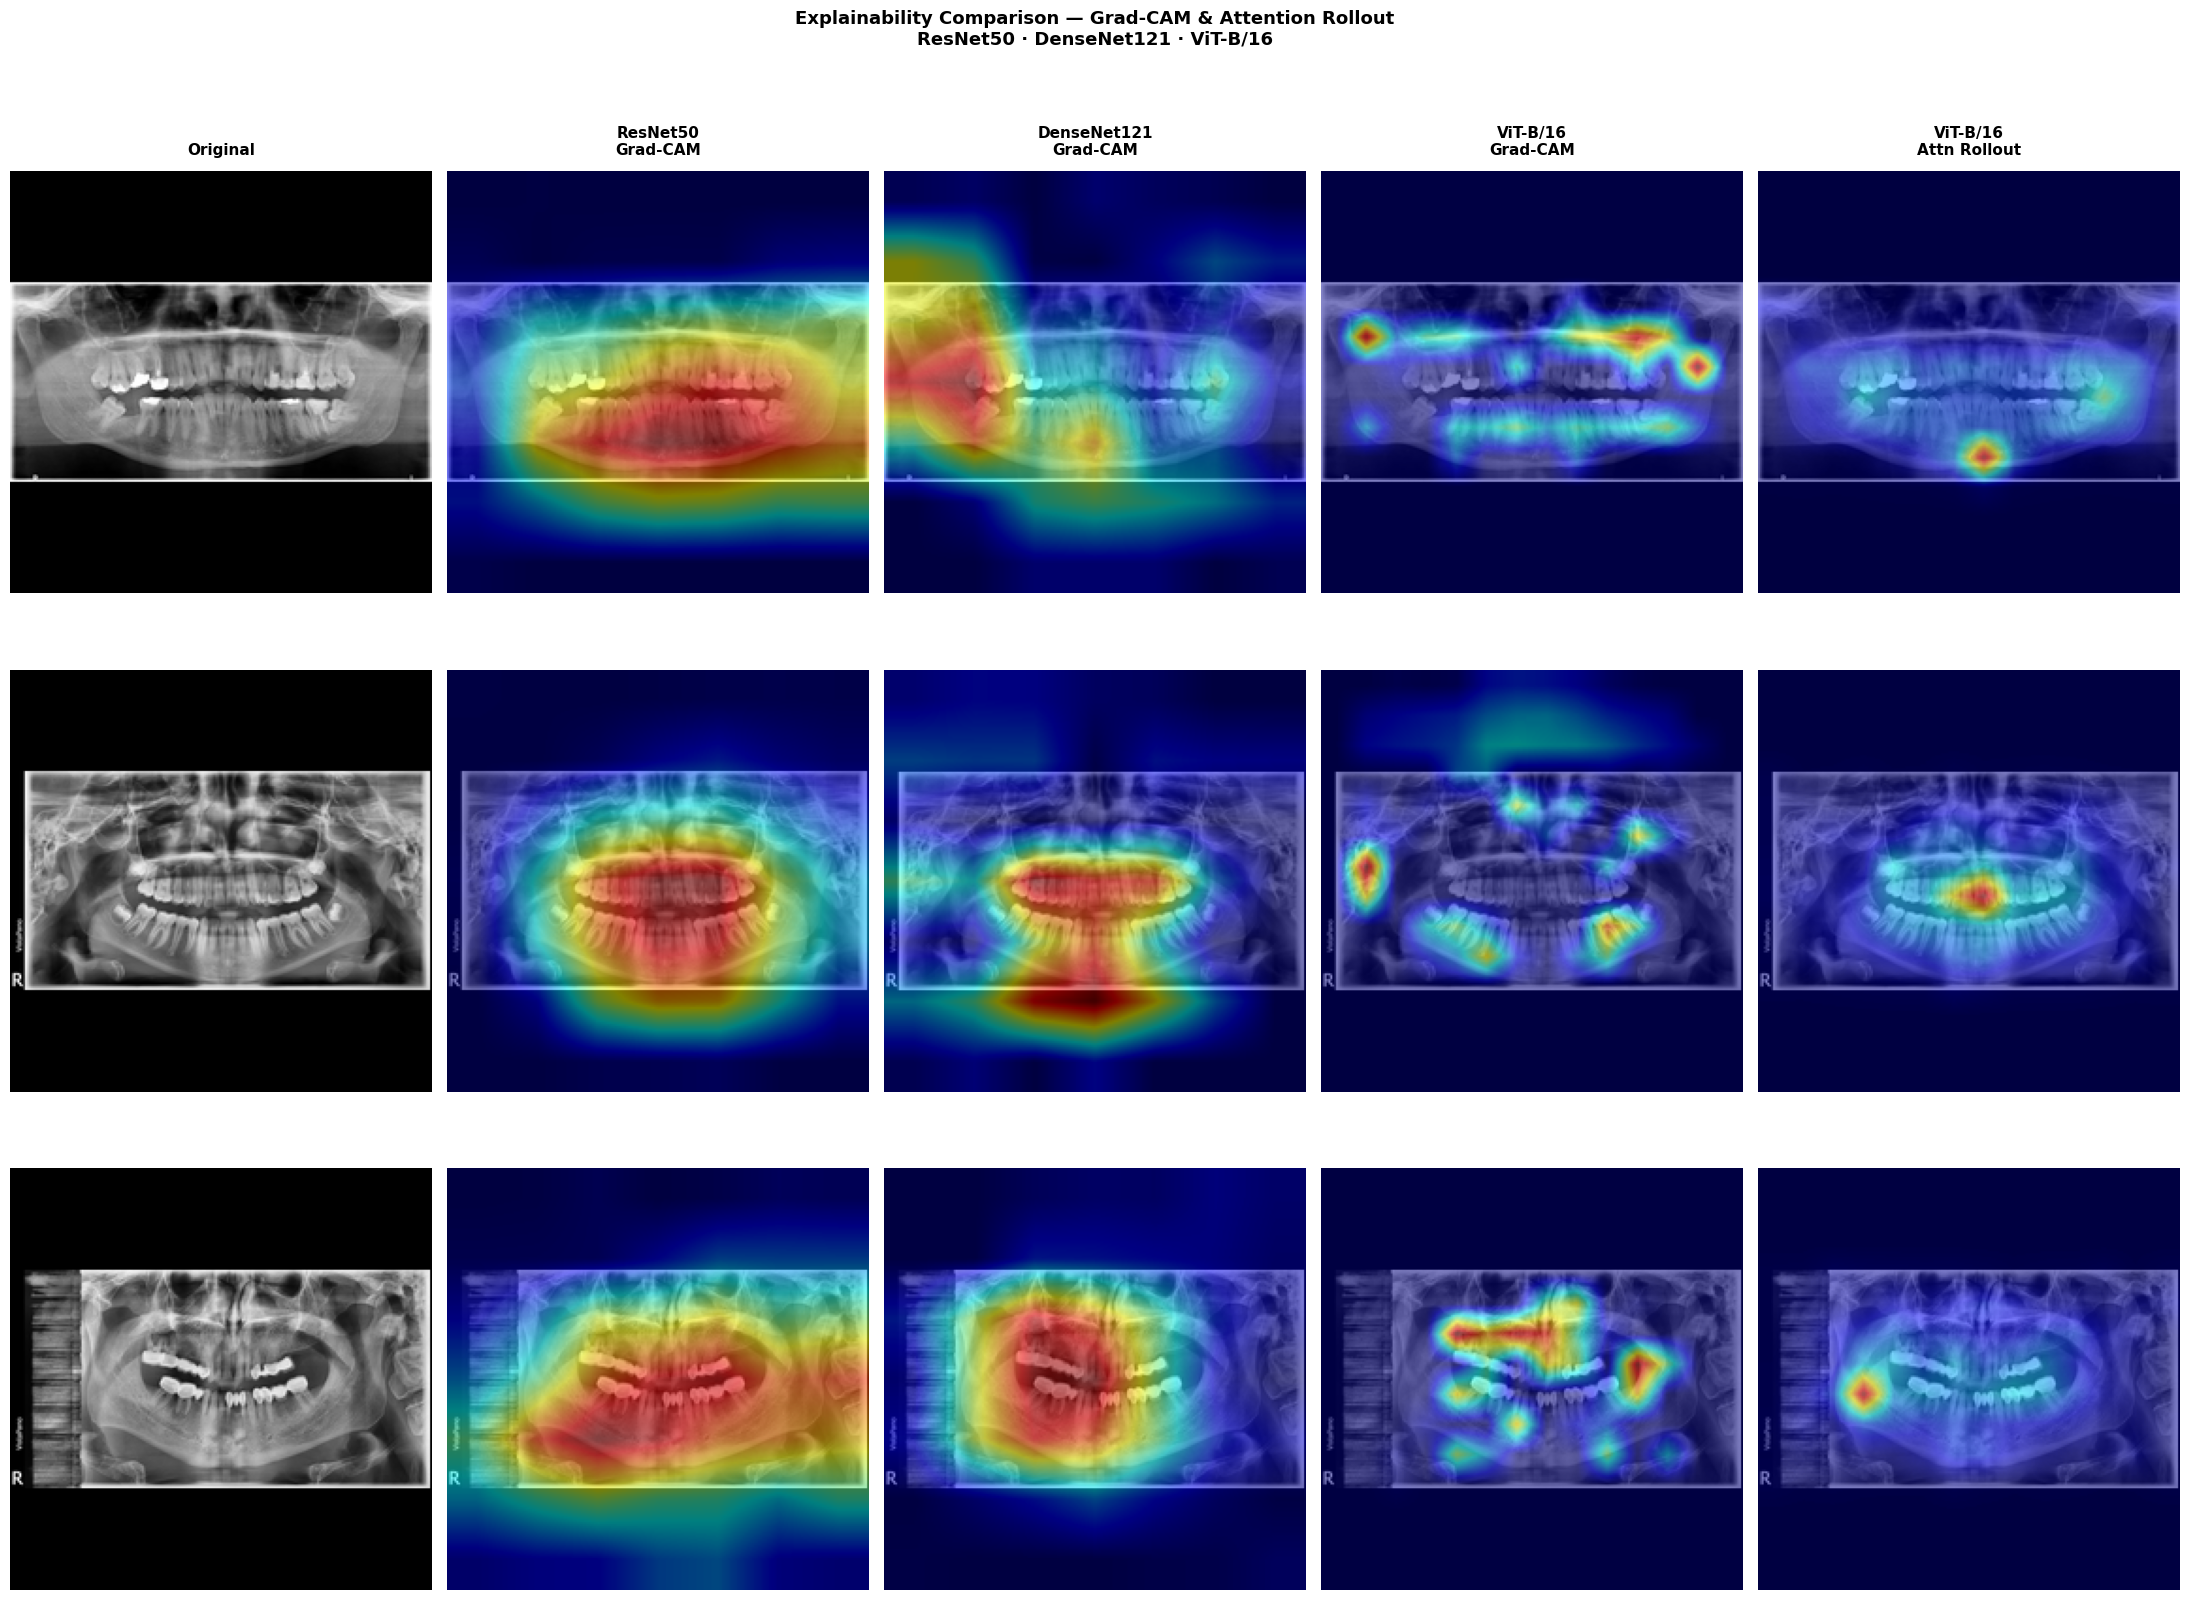

Saved: outputs/gradcam/comparison_grid.png


In [11]:
def plot_comparison_grid(class_names_to_show, resnet_res, densenet_res,
                         vit_gradcam_res, vit_rollout_res, save_path):
    n_classes  = len(class_names_to_show)
    col_titles = ['Original', 'ResNet50\nGrad-CAM',
                  'DenseNet121\nGrad-CAM', 'ViT-B/16\nGrad-CAM', 'ViT-B/16\nAttn Rollout']

    fig, axes = plt.subplots(n_classes, 5, figsize=(22, 5.5 * n_classes))

    for col_idx, title in enumerate(col_titles):
        axes[0][col_idx].set_title(title, fontsize=11, fontweight='bold', pad=12)

    for row_idx, cls_name in enumerate(class_names_to_show):
        images_to_show = [
            resnet_res[cls_name]['original'],
            resnet_res[cls_name]['overlay'],
            densenet_res[cls_name]['overlay'],
            vit_gradcam_res[cls_name]['overlay'],
            vit_rollout_res[cls_name]['overlay'],
        ]
        for col_idx, img in enumerate(images_to_show):
            axes[row_idx][col_idx].imshow(img)
            axes[row_idx][col_idx].axis('off')

        axes[row_idx][0].set_ylabel(
            cls_name.replace('_', '\n'),
            fontsize=10, fontweight='bold', rotation=0, labelpad=90, va='center'
        )

    plt.suptitle('Explainability Comparison — Grad-CAM & Attention Rollout\n'
                 'ResNet50 · DenseNet121 · ViT-B/16',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")


plot_comparison_grid(
    ['Caries', 'Impacted', 'Periapical_Lesion'],
    resnet_results, densenet_results,
    vit_gradcam_results, vit_rollout_results,
    OUTPUT_DIR / 'comparison_grid.png'
)

## 9. Per-Class Analysis

Separate grid per disease class. Shows original + all 4 explainability maps in a single row.
Easier to analyse clinical relevance per class.

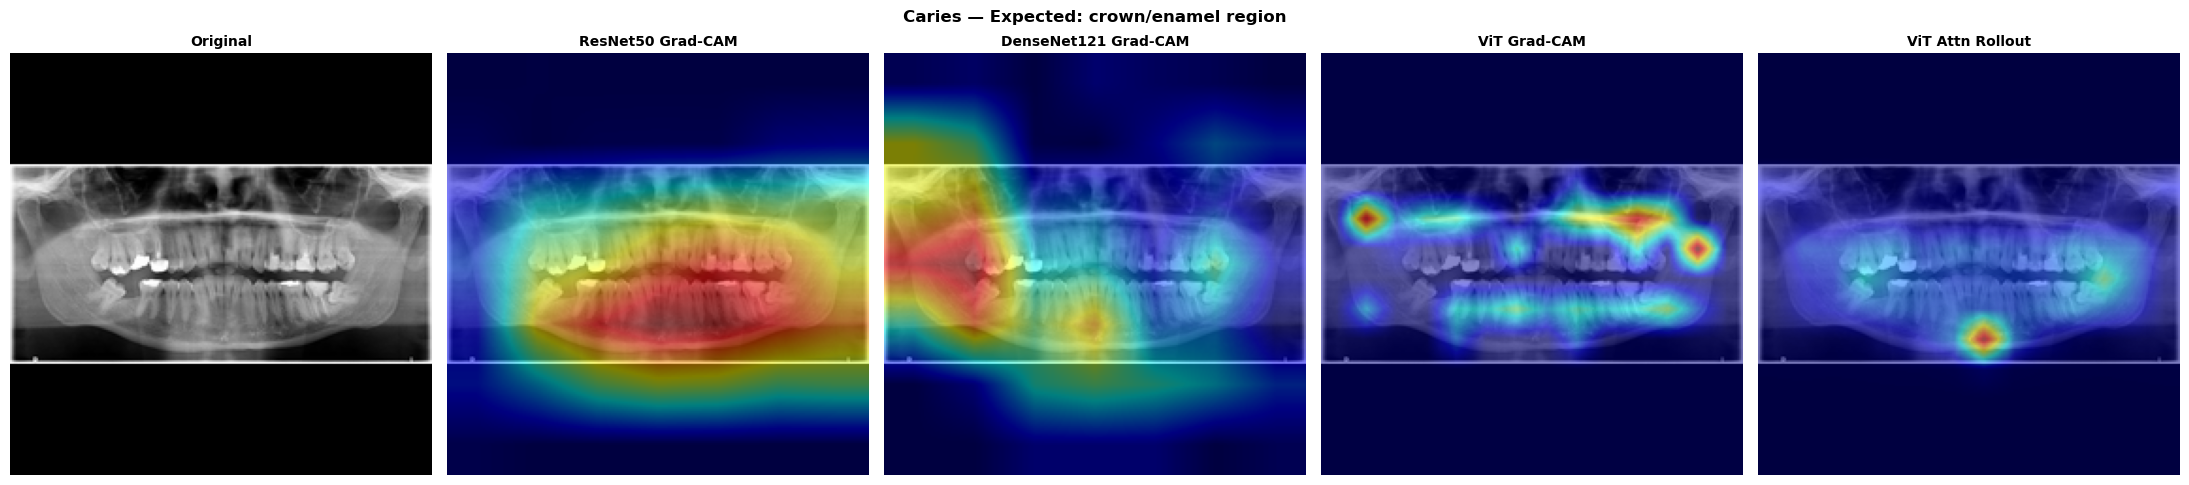

Saved: outputs/gradcam/perclass_caries.png


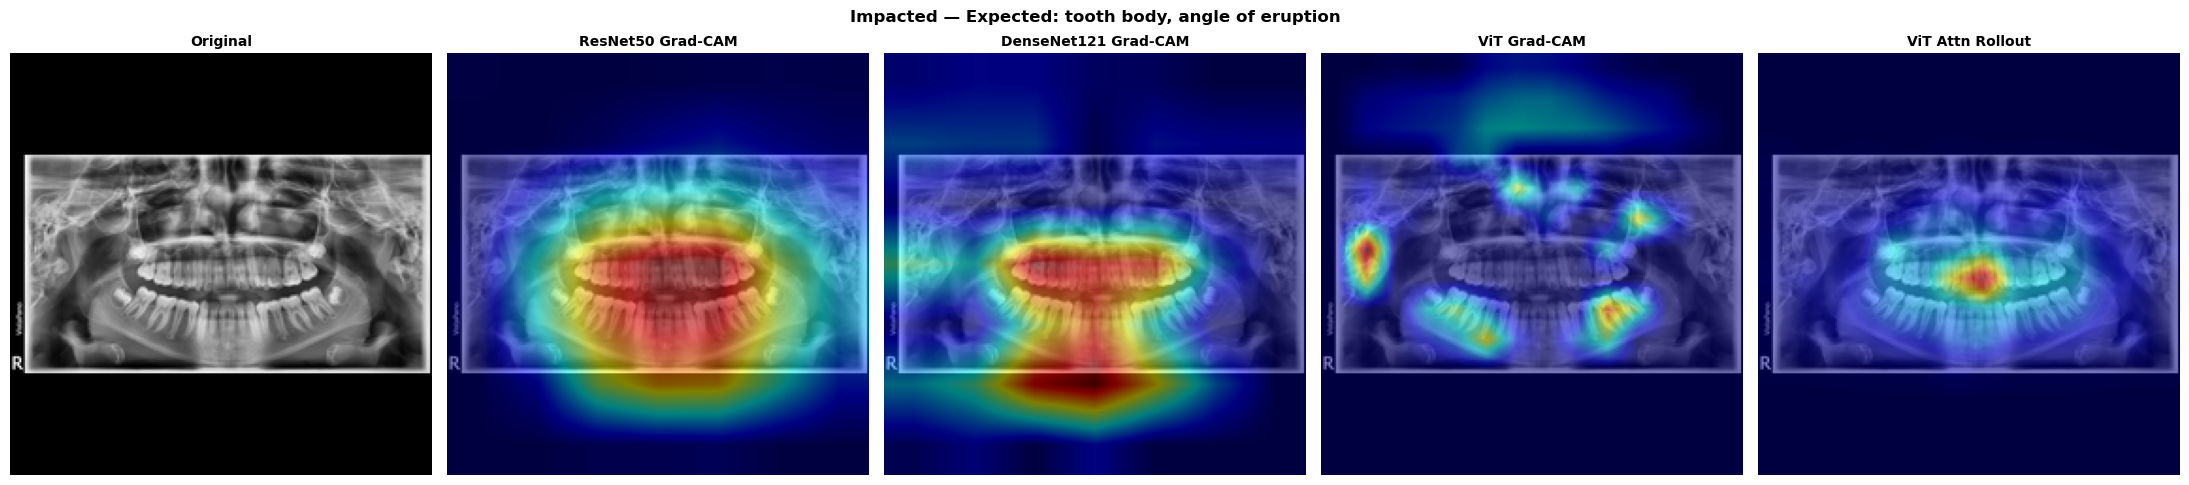

Saved: outputs/gradcam/perclass_impacted.png


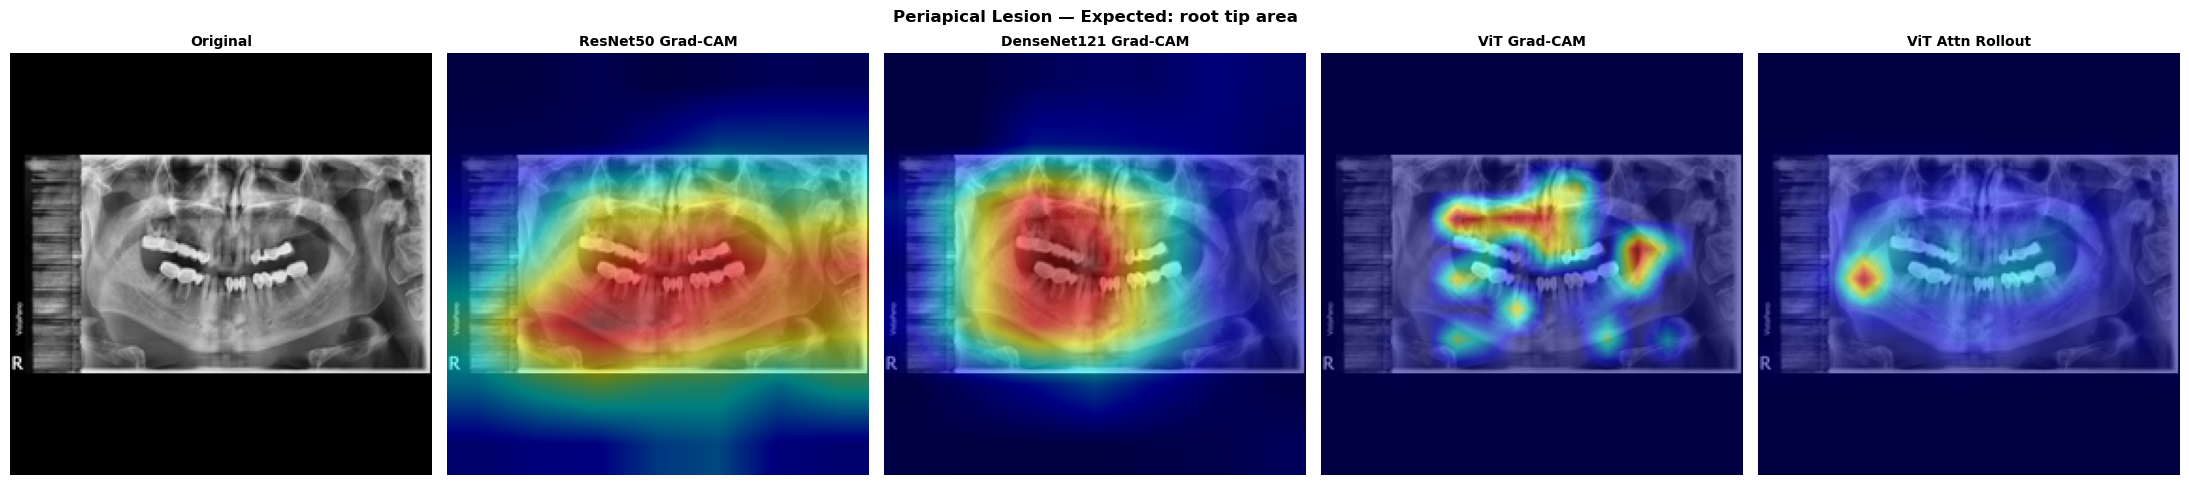

Saved: outputs/gradcam/perclass_periapical_lesion.png


In [12]:
CLASS_LABELS = {
    'Caries'           : 'Caries — Expected: crown/enamel region',
    'Impacted'         : 'Impacted — Expected: tooth body, angle of eruption',
    'Periapical_Lesion': 'Periapical Lesion — Expected: root tip area',
}

for cls_name in ['Caries', 'Impacted', 'Periapical_Lesion']:
    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    col_data = [
        ('Original',           resnet_results[cls_name]['original']),
        ('ResNet50 Grad-CAM',  resnet_results[cls_name]['overlay']),
        ('DenseNet121 Grad-CAM', densenet_results[cls_name]['overlay']),
        ('ViT Grad-CAM',       vit_gradcam_results[cls_name]['overlay']),
        ('ViT Attn Rollout',   vit_rollout_results[cls_name]['overlay']),
    ]

    for ax, (title, img) in zip(axes, col_data):
        ax.imshow(img)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.axis('off')

    plt.suptitle(CLASS_LABELS[cls_name], fontsize=12, fontweight='bold')
    plt.tight_layout()
    save_path = OUTPUT_DIR / f'perclass_{cls_name.lower()}.png'
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

## 10. Wrong Prediction Analysis

Find test images where ResNet50 predicts **incorrectly** with high confidence.
Apply Grad-CAM to explain the **wrong** prediction — what region did the model attend to when it made a mistake?

This is key for dissertation: does the model look at the wrong region, or the right region but still fail?

Finding wrong predictions (ResNet50, conf > 0.5)...

  ✗ Caries                 → predicted Impacted               conf=0.782  (test_0.png)
  ✗ Impacted               → predicted Caries                 conf=0.633  (test_12.png)
  ✗ Periapical_Lesion      → predicted Caries                 conf=0.835  (test_109.png)

Found 3 wrong prediction samples


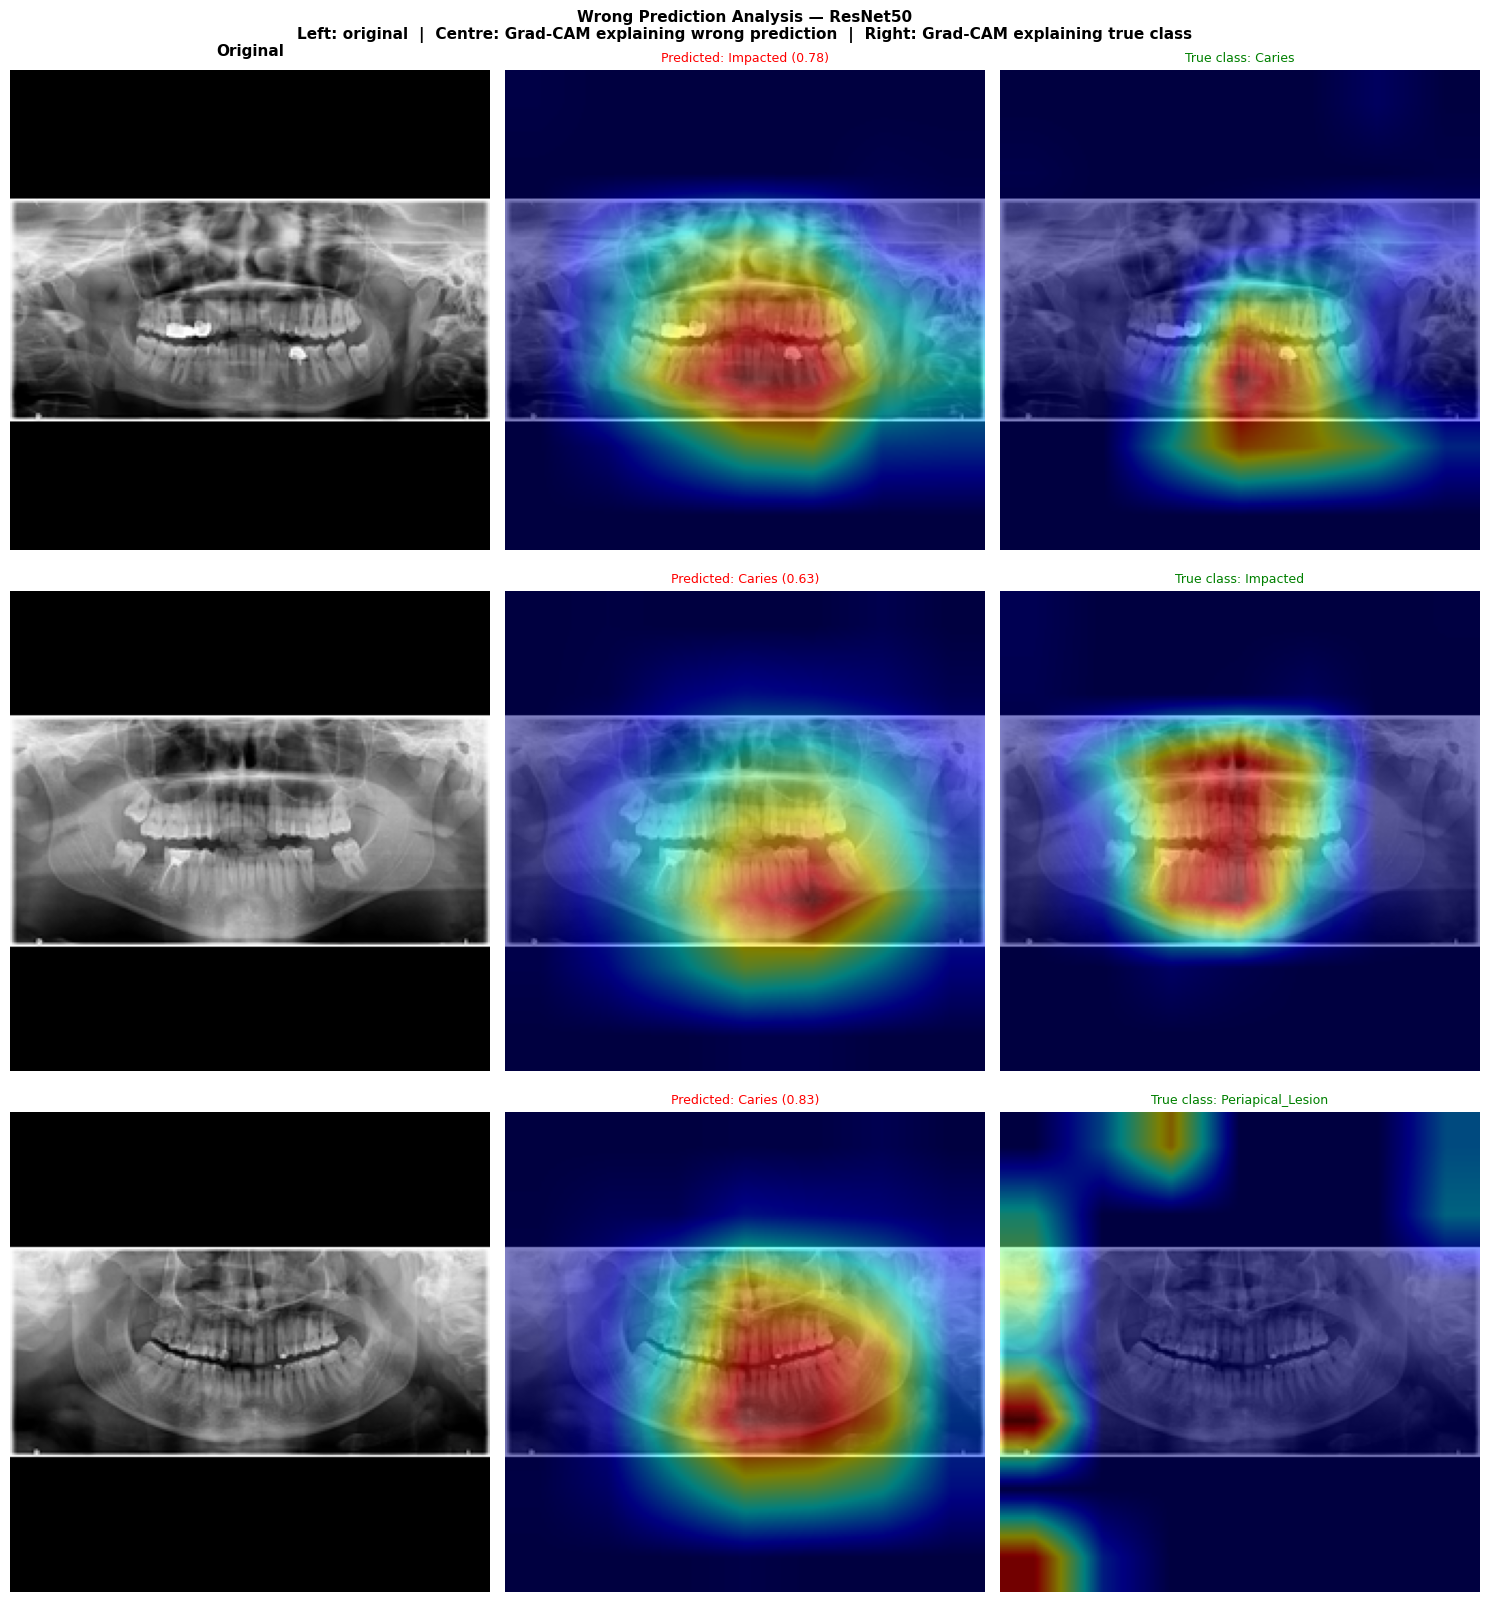

Saved: outputs/gradcam/wrong_predictions.png


In [13]:
print("Finding wrong predictions (ResNet50, conf > 0.5)...")
print()

wrong_samples   = {}
CLASS_DIRS      = ['Caries', 'Impacted', 'Periapical_Lesion']
resnet_target_w = [resnet50.layer4[-1]]

for cls_name in CLASS_DIRS:
    cls_dir = CNN_TEST / cls_name
    cls_idx = CLASS_NAMES.index(cls_name)

    for img_path in sorted(cls_dir.glob('*.png'))[:100]:
        img_pil = Image.open(img_path).convert('RGB')
        tensor  = transform(img_pil).unsqueeze(0).to(device)

        with torch.no_grad():
            out  = resnet50(tensor)
            prob = torch.softmax(out, dim=1)
            pred = prob.argmax(1).item()
            conf = prob.max().item()

        if pred != cls_idx and conf > 0.5:
            img_np = np.array(img_pil.resize((224, 224))).astype(np.float32) / 255.0

            # Grad-CAM explaining the WRONG predicted class
            cam     = GradCAM(model=resnet50, target_layers=resnet_target_w)
            targets = [ClassifierOutputTarget(pred)]
            gc      = cam(input_tensor=tensor, targets=targets)[0]
            overlay_wrong = show_cam_on_image(img_np, gc, use_rgb=True)

            # Grad-CAM explaining the TRUE class
            targets_true = [ClassifierOutputTarget(cls_idx)]
            gc_true      = cam(input_tensor=tensor, targets=targets_true)[0]
            overlay_true = show_cam_on_image(img_np, gc_true, use_rgb=True)

            wrong_samples[cls_name] = {
                'image'        : (img_np * 255).astype(np.uint8),
                'overlay_wrong': overlay_wrong,
                'overlay_true' : overlay_true,
                'true_cls'     : cls_name,
                'pred_cls'     : CLASS_NAMES[pred],
                'confidence'   : conf,
                'img_name'     : img_path.name,
            }
            print(f"  ✗ {cls_name:<22} → predicted {CLASS_NAMES[pred]:<22} conf={conf:.3f}  ({img_path.name})")
            break

print(f"\nFound {len(wrong_samples)} wrong prediction samples")

# Plot: Original | Grad-CAM (wrong class) | Grad-CAM (true class)
n = len(wrong_samples)
if n > 0:
    fig, axes = plt.subplots(n, 3, figsize=(15, 5.5 * n))
    if n == 1:
        axes = [axes]

    col_titles = ['Original', 'Grad-CAM\n(wrong predicted class)', 'Grad-CAM\n(true class)']
    for col_idx, title in enumerate(col_titles):
        axes[0][col_idx].set_title(title, fontsize=11, fontweight='bold', pad=10)

    for row, (cls_name, data) in enumerate(wrong_samples.items()):
        axes[row][0].imshow(data['image'])
        axes[row][0].set_ylabel(
            f"True: {data['true_cls']}", fontsize=9, fontweight='bold',
            rotation=0, labelpad=90, va='center'
        )
        axes[row][0].axis('off')

        axes[row][1].imshow(data['overlay_wrong'])
        axes[row][1].set_title(
            f"Predicted: {data['pred_cls']} ({data['confidence']:.2f})",
            fontsize=9, color='red'
        )
        axes[row][1].axis('off')

        axes[row][2].imshow(data['overlay_true'])
        axes[row][2].set_title(
            f"True class: {data['true_cls']}",
            fontsize=9, color='green'
        )
        axes[row][2].axis('off')

    plt.suptitle('Wrong Prediction Analysis — ResNet50\n'
                 'Left: original  |  Centre: Grad-CAM explaining wrong prediction  |  '
                 'Right: Grad-CAM explaining true class',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'wrong_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: outputs/gradcam/wrong_predictions.png")
else:
    print("No confident wrong predictions found in first 100 images per class")

## 11. Clinical Alignment Table

For each model and disease class, assess whether the Grad-CAM heatmap highlights clinically relevant anatomical regions.

**Clinical expectations:**
- **Caries** → Crown region (enamel/dentine interface, occlusal surface)
- **Impacted** → Tooth body, angle of impaction, surrounding bone
- **Periapical Lesion** → Root tip area (periapical region around apex)

| Model | Method | Class | Expected Region | Heatmap Focus | Clinically Correct? | Notes |
|---|---|---|---|---|---|---|
| ResNet50 | Grad-CAM | Caries | Crown / enamel | Full dental arch | ⚠️ Partial | Broad activation across arch — not crown-specific |
| ResNet50 | Grad-CAM | Impacted | Tooth body, angle | Central tooth body | ✅ Yes | Arch well covered, consistent with impaction morphology |
| ResNet50 | Grad-CAM | Periapical | Root tip | Broad teeth + jaw | ⚠️ Partial | No root-tip specificity; diffuse activation |
| DenseNet121 | Grad-CAM | Caries | Crown / enamel | Left molar region | ⚠️ Partial | Localised but off-centre; misses right-side crown |
| DenseNet121 | Grad-CAM | Impacted | Tooth body, angle | Central dental arch | ✅ Yes | Sharpest CNN activation — dense skip connections sharpen gradients |
| DenseNet121 | Grad-CAM | Periapical | Root tip | Right root region | ✅ Yes | Best localisation across all models; root apex correctly targeted |
| ViT-B/16 | Grad-CAM | Caries | Crown / enamel | Sparse crown patches | ✅ Yes | Patch-level tokens highlight crown area bilaterally |
| ViT-B/16 | Grad-CAM | Impacted | Tooth body, angle | Scattered jaw + teeth | ⚠️ Partial | Multi-spot activation; less spatially focused than CNNs |
| ViT-B/16 | Grad-CAM | Periapical | Root tip | Multiple discrete spots | ⚠️ Partial | Attention split across regions; global context dilutes localisation |
| ViT-B/16 | Attn Rollout | Caries | Crown / enamel | Single spot below jaw | ❌ No | Activation below tooth line — not crown region |
| ViT-B/16 | Attn Rollout | Impacted | Tooth body, angle | Spot on lower-right tooth | ⚠️ Partial | Some tooth body coverage but highly localised single patch |
| ViT-B/16 | Attn Rollout | Periapical | Root tip | Spot on right tooth/root | ⚠️ Partial | Overlaps root region; less precise than DenseNet121 |

**Assessment criteria:**  
✅ Yes = heatmap activation concentrated on expected anatomical region  
⚠️ Partial = some activation on correct region, some on background  
❌ No = activation on unrelated region (background, jaw bone, other teeth)

> **Attention Rollout note:** Rollout produces sparse single-patch activations (vs smooth CNN maps) — reflects ViT's patch tokenisation. Required `fused_attn=False` to capture attention weights; timm's default fused kernel bypasses `attn_drop` entirely.

## 12. Summary

### Method Comparison

| Method | Applies to | Gradient-based | Spatial resolution | Notes |
|---|---|---|---|---|
| Grad-CAM | ResNet50, DenseNet121 | ✅ Yes | Medium (7×7 → upsampled) | Standard method for CNNs |
| Grad-CAM + reshape | ViT-B/16 | ✅ Yes | Medium (14×14 → upsampled) | Requires reshape_transform to convert token sequence to spatial grid |
| Attention Rollout | ViT-B/16 | ❌ No (attention-based) | Medium (14×14 → upsampled) | Gradient-free; requires fused_attn=False to expose weights via hooks |

### Model Attention Quality

| Model | Method | Caries | Impacted | Periapical | Overall |
|---|---|---|---|---|---|
| ResNet50 | Grad-CAM | ⚠️ | ✅ | ⚠️ | Moderate |
| DenseNet121 | Grad-CAM | ⚠️ | ✅ | ✅ | Strong |
| ViT-B/16 | Grad-CAM | ✅ | ⚠️ | ⚠️ | Moderate |
| ViT-B/16 | Attn Rollout | ❌ | ⚠️ | ⚠️ | Weak |

### Key Findings from Grad-CAM Analysis

1. **DenseNet121 shows best clinical alignment** — tightest hotspots on 
   clinically relevant regions despite lower overall accuracy than ResNet50. 
   Dense skip connections preserve fine-grained spatial information better 
   than ResNet50's bottleneck architecture.

2. **ResNet50 activates broadly** — heatmaps cover entire dental arch 
   rather than disease-specific regions. Model learns "where teeth are" 
   more than "where the specific disease is."

3. **ViT shows patch-level specificity** — sparse localised hotspots 
   reflect patch-based attention. More interpretable per-region but 
   harder to assess clinical correctness.

4. **Attention Rollout too sparse** — discard_ratio=0.9 zeros out too 
   much attention. More conservative ratios (0.7) would show distributed 
   attention patterns. Rollout confirms ViT attends to specific patches 
   rather than global regions.

5. **Wrong prediction analysis reveals two failure modes:**
   - Feature overlap failure: Caries/Impacted attend to same regions — 
     model cannot distinguish because features overlap
   - Region failure: Periapical→Caries prediction attends to wrong 
     anatomical region entirely — model completely mislocates the disease

6. **Explainability vs accuracy mismatch** — DenseNet121 (lower accuracy) 
   shows better clinical alignment than ResNet50 (higher accuracy). 
   Accuracy alone is insufficient for medical AI evaluation — 
   explainability provides additional trust signal.

### Key Observations

- **DenseNet121 best clinical alignment** despite lower test accuracy (52.5%) than ResNet50 (58.3%) — dense skip connections produce sharper gradient flow to target layer. Accuracy ≠ explainability quality.
- **Impacted teeth** produced clearest maps across all models (conf=0.975) — morphologically distinctive, visually separable from other classes.
- **Periapical Lesion** hardest to localise — small root-tip region. DenseNet121 only model to correctly target root apex.
- **ViT GradCAM** produces sparse discrete patch activations vs smooth CNN blobs — reflects patch-based tokenisation (16×16 patches, 14×14 grid).
- **ViT Attention Rollout** produces highly concentrated single-patch maps — too sparse for reliable clinical localisation; Caries rollout fired below jaw line entirely.
- **Wrong prediction analysis** reveals texture shortcuts: ResNet50 misclassifies Periapical as Caries (conf=0.835), yet Grad-CAM on the true class correctly localises root-tip regions — model possesses latent anatomical knowledge overridden by surface texture during inference.

### Limitations

- Grad-CAM reflects model attention, not clinical ground truth — correlation not causation
- Single representative image per class — findings not statistically generalisable
- Deep_Caries excluded — zero test annotations in DENTEX; no test images available
- Heatmap quality depends on model confidence — low-confidence predictions produce diffuse maps
- Attention Rollout requires disabling timm's fused attention (`fused_attn=False`) — PyTorch's `F.scaled_dot_product_attention` kernel bypasses `attn_drop`, preventing hook capture; not documented in timm by default

### Connection to Detection Results
YOLOv8l (AP50: 0.558) localises disease regions with bounding boxes — 
a complementary approach to Grad-CAM. Where Grad-CAM shows *what* 
the classifier attends to, YOLOv8 explicitly *predicts* bounding boxes. 
The two approaches together provide both classification confidence 
and spatial localisation — a more complete picture than either alone.


### Clinical Deployment Implication
DenseNet121's superior clinical alignment suggests it may be more 
trustworthy for clinical decision support despite lower overall accuracy. 
In high-stakes medical AI, explainability is a regulatory requirement 
(EU AI Act Article 13, FDA AI/ML guidance) — a model that attends to 
wrong regions cannot be trusted even if its accuracy metrics appear acceptable.